# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [1]:
%pip install transformers torch tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [20]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForMaskedLM, BertForSequenceClassification
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup, data_utils
from src.models import bert

## B. Data Loading

In [ ]:
data_frac = data_utils.DATA_FRACTION

Using device: mps


In [4]:
df_train, df_val, df_test = data_utils.load_datasets()

# Load data as Hugging Face Datasets
ds_train, ds_val, ds_test = bert.create_datasets(df_train, df_val, df_test)

## C. Tokenization

In [5]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [6]:
bert.max_length_dist(df_train, 'tweet_text', tokenizer)

90th percentile: 44.0
95th percentile: 50.0
99th percentile: 61.0
Absolute Maximum length: 158


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [13]:
save_path = Path(f"../tokens/BERT/{data_frac}")
train_tokenized, val_tokenized, test_tokenized = bert.load_or_tokenize(ds_train, ds_val, ds_test, tokenizer, save_path)

Tokenizing datasets...


Map: 100%|██████████| 3747/3747 [00:00<00:00, 43293.37 examples/s]


Saving tokenized datasets to ../tokens/BERT/0.1...


Saving the dataset (1/1 shards): 100%|██████████| 3747/3747 [00:00<00:00, 451338.48 examples/s]


## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

In [ ]:
# # Comment out this cell to use the full dataset. This is just for quick testing.
# train_size = 1000
# train_tokenized = train_tokenized.select(range(train_size))
# val_tokenized = val_tokenized.select(range(int(train_size / 4)))
# test_tokenized = test_tokenized.select(range(int(train_size / 4)))

### B.1. Preparation

In [ ]:
device = setup.setup_device_with_seeds()

batch_size = 16
learning_rate = 5e-5
num_epochs = 3
patience = 2  # early stopping, if validation loss does not improve for this many epochs

train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

# Optimizer
bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [26]:
model, train_loss_history, val_loss_history, val_acc_history = bert.finetune(train_tokenized, val_tokenized, configs)

Validating Epoch 1/3: 100%|██████████| 16/16 [00:02<00:00,  6.72it/s]


Epoch 1/3 | Train Loss: 0.2598 | Val Loss: 0.1823 | Val Acc: 0.9400


Validating Epoch 2/3: 100%|██████████| 16/16 [00:02<00:00,  7.25it/s]


Epoch 2/3 | Train Loss: 0.1173 | Val Loss: 0.1623 | Val Acc: 0.9320


Validating Epoch 3/3: 100%|██████████| 16/16 [00:02<00:00,  7.47it/s]


Epoch 3/3 | Train Loss: 0.0673 | Val Loss: 0.1806 | Val Acc: 0.9480
Loaded best model with Val Loss: 0.1623


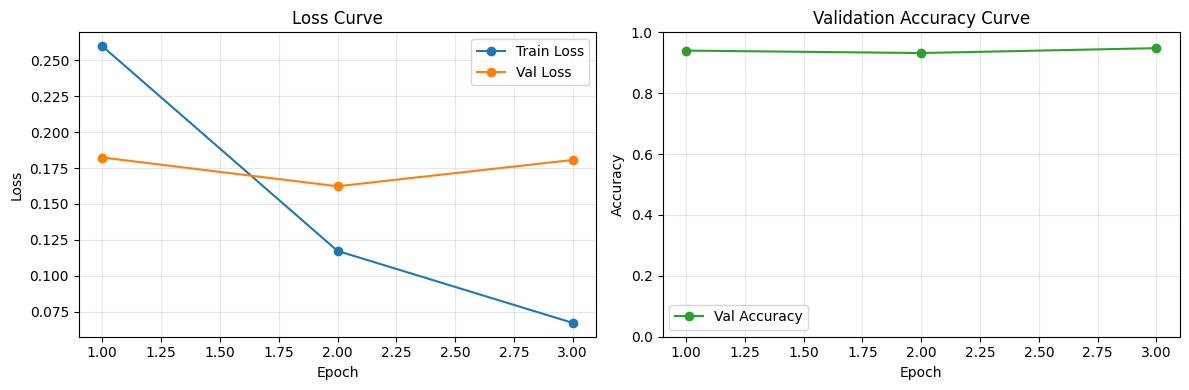

In [ ]:
data_utils.plot_fine_tune_history(train_loss_history, val_loss_history, val_acc_history)

### B.3. Predict on the Test set

In [ ]:
predictions = bert.predict(model, test_tokenized, device)

Predicting on Test Set: 100%|██████████| 16/16 [00:05<00:00,  2.88it/s]


In [ ]:
bert.report_metrics(test_tokenized, predictions)

Test Accuracy: 0.9560
Test F1 (macro): 0.9407

Classification report:
              precision    recall  f1-score   support

           0     0.9734    0.9683    0.9708       189
           1     0.9032    0.9180    0.9106        61

    accuracy                         0.9560       250
   macro avg     0.9383    0.9431    0.9407       250
weighted avg     0.9563    0.9560    0.9561       250

